In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix,accuracy_score,
precision_score,recall_score,f1_score,classification_report)
from sklearn.preprocessing import LabelEncoder, StandardScaler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [4]:
data=pd.read_csv(r"C:\Users\nisht\Desktop\E commerce dataset.csv")
print(data.head())

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore MaritalStatus  Number

In [5]:
#data type
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [6]:
#data cleaning
print(data.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


In [7]:
#missing values in %
print(data.isnull().sum()*100/len(data))
#if missing values are 5-10%, then we can impute it by median

CustomerID                     0.000000
Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64


In [9]:
#Null value imputation by median
miss_columns= ['Tenure','WarehouseToHome','HourSpendOnApp',
               'OrderAmountHikeFromlastYear','CouponUsed',
               'OrderCount','DaySinceLastOrder']
for column in list(miss_columns):
    data[column].fillna(data[column].median(),inplace=True)

In [10]:
print(data.isnull().sum()*100/len(data))
#Now missing values are 0%

CustomerID                     0.0
Churn                          0.0
Tenure                         0.0
PreferredLoginDevice           0.0
CityTier                       0.0
WarehouseToHome                0.0
PreferredPaymentMode           0.0
Gender                         0.0
HourSpendOnApp                 0.0
NumberOfDeviceRegistered       0.0
PreferedOrderCat               0.0
SatisfactionScore              0.0
MaritalStatus                  0.0
NumberOfAddress                0.0
Complain                       0.0
OrderAmountHikeFromlastYear    0.0
CouponUsed                     0.0
OrderCount                     0.0
DaySinceLastOrder              0.0
CashbackAmount                 0.0
dtype: float64


In [13]:
#checking unique values
for col in data.columns:
    print(col)
    print(data[col].unique())
    print("")

CustomerID
[50001 50002 50003 ... 55628 55629 55630]

Churn
[1 0]

Tenure
[ 4.  9.  0. 13. 11. 19. 20. 14.  8. 18.  5.  2. 30.  1. 23.  3. 29.  6.
 26. 28.  7. 24. 25. 10. 15. 22. 27. 16. 12. 21. 17. 50. 60. 31. 51. 61.]

PreferredLoginDevice
['Mobile Phone' 'Phone' 'Computer']

CityTier
[3 1 2]

WarehouseToHome
[  6.   8.  30.  15.  12.  22.  11.   9.  31.  18.  13.  20.  29.  28.
  26.  14.  10.  27.  17.  23.  33.  19.  35.  24.  16.  25.  32.  34.
   5.  21. 126.   7.  36. 127.]

PreferredPaymentMode
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender
['Female' 'Male']

HourSpendOnApp
[3. 2. 1. 0. 4. 5.]

NumberOfDeviceRegistered
[3 4 5 2 1 6]

PreferedOrderCat
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

SatisfactionScore
[2 3 5 4 1]

MaritalStatus
['Single' 'Divorced' 'Married']

NumberOfAddress
[ 9  7  6  8  3  2  4 10  1  5 19 21 11 20 22]

Complain
[1 0]

OrderAmountHikeFromlastYear
[11. 15. 14. 23. 22. 16. 12. 13

In [14]:
#In preferred login device-
#Mobile phones and phones are same, so we need to merge 
data['PreferredLoginDevice']= data['PreferredLoginDevice'].replace({
    'Phone': 'Mobile Phone'})

data['PreferredLoginDevice'].value_counts()

PreferredLoginDevice
Mobile Phone    3996
Computer        1634
Name: count, dtype: int64

In [15]:
#For preferred payment methods
#CC and credit card are same
#COD and cash on delivery are same
data['PreferredPaymentMode']=data['PreferredPaymentMode'].replace({
    'CC': 'Credit Card'})
data['PreferredPaymentMode']=data['PreferredPaymentMode'].replace({
    'COD': 'Cash on Delivery'})

data['PreferredPaymentMode'].value_counts()

PreferredPaymentMode
Debit Card          2314
Credit Card         1774
E wallet             614
Cash on Delivery     514
UPI                  414
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='CashbackAmount'>

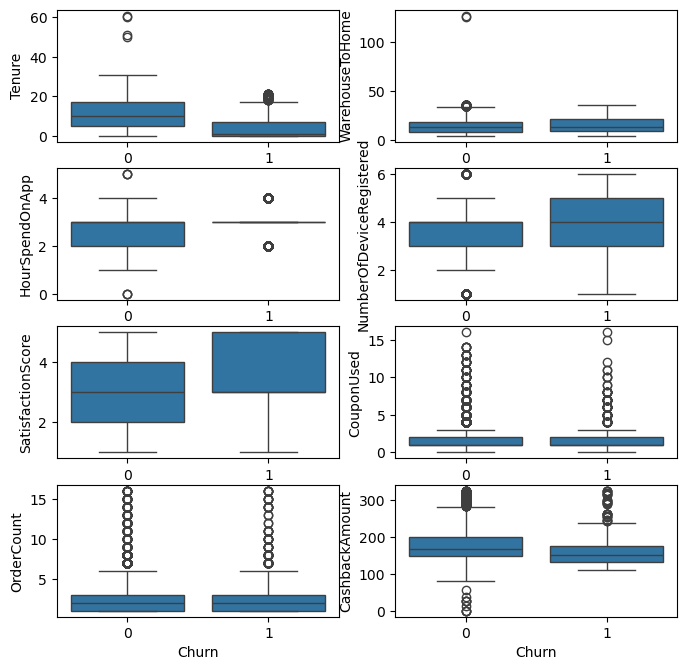

In [17]:
#EDA
#visualizing numerical variables

plt.figure(figsize=(8,12))
plt.subplot(6,2,1)
sns.boxplot(x='Churn',y='Tenure',data=data)

plt.subplot(6,2,2)
sns.boxplot(x='Churn',y='WarehouseToHome',data=data)

plt.subplot(6,2,3)
sns.boxplot(x='Churn',y='HourSpendOnApp',data=data)

plt.subplot(6,2,4)
sns.boxplot(x='Churn',y='NumberOfDeviceRegistered',data=data)

plt.subplot(6,2,5)
sns.boxplot(x='Churn',y='SatisfactionScore',data=data)

plt.subplot(6,2,6)
sns.boxplot(x='Churn',y='CouponUsed',data=data)

plt.subplot(6,2,7)
sns.boxplot(x='Churn',y='OrderCount',data=data)

plt.subplot(6,2,8)
sns.boxplot(x='Churn',y='CashbackAmount',data=data)

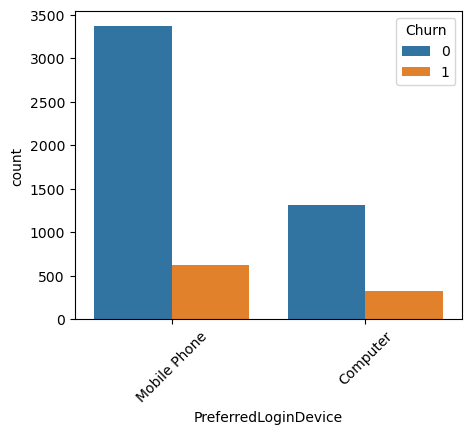

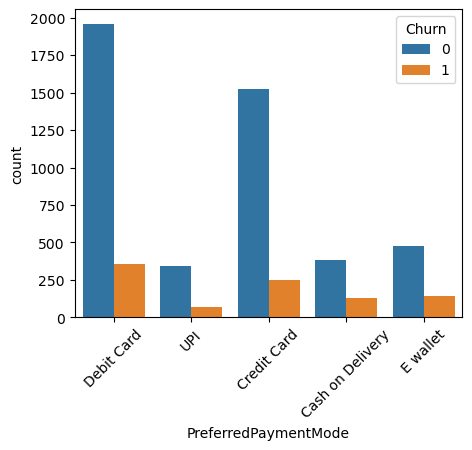

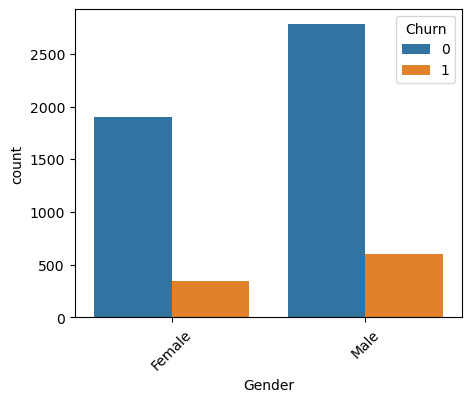

In [24]:
#plots for categorical data
plt.figure(figsize=(5,4))
sns.countplot(x='PreferredLoginDevice',hue='Churn',data=data)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x='PreferredPaymentMode',hue='Churn',data=data)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(5,4))
sns.countplot(x='Gender',hue='Churn',data=data)
plt.xticks(rotation=45)
plt.show()


In [25]:
#Encoding categorical variables
le= LabelEncoder()
for col in data.select_dtypes(include='object').columns:
    data[col]=le.fit_transform(data[col])

In [26]:
#Train test split
x= data.drop('Churn',axis=1)
y= data['Churn']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [34]:
#feature scaling
scaler=StandardScaler()

x_train1= scaler.fit_transform(x_train)
x_test1=scaler.transform(x_test)


In [35]:
#fitting logistic model
x_constant= sm.add_constant(x_train1)
model=sm.Logit(y_train,x_constant).fit()
print(model.summary())

#predicted values
x1_const= sm.add_constant(x_test1)
y_pred_test= model.predict(x1_const)

Optimization terminated successfully.
         Current function value: 0.298214
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 4504
Model:                          Logit   Df Residuals:                     4484
Method:                           MLE   Df Model:                           19
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                  0.3445
Time:                        12:51:23   Log-Likelihood:                -1343.2
converged:                       True   LL-Null:                       -2049.1
Covariance Type:            nonrobust   LLR p-value:                3.757e-288
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6857      0.081    -33.125      0.000      -2.845      -2.527
x1            -0.4002      0.

confusion matrix


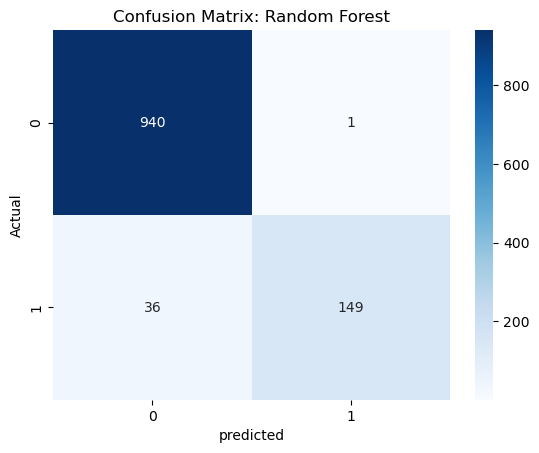

In [36]:
#random forest model
rf_model= RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(x_train,y_train)

y_pred_rf= rf_model.predict(x_test1)
print("confusion matrix")

#evaluation metrics
cm=confusion_matrix(y_test,y_pred_rf)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix: Random Forest")
plt.show()